Year       Mean       P5      P50      P95   P(<1.2x)
--------------------------------------------------
  1        1.20x     0.97x     1.19x     1.44x      51.9%
  2        1.25x     1.00x     1.24x     1.49x      38.1%
  3        1.30x     1.05x     1.30x     1.56x      26.2%
  4        1.36x     1.09x     1.36x     1.62x      17.0%
  5        1.42x     1.15x     1.42x     1.70x       8.8%
  6        1.49x     1.21x     1.49x     1.78x       4.5%
  7        1.57x     1.27x     1.57x     1.87x       2.0%
  8        1.65x     1.34x     1.65x     1.97x       0.8%
  9        2.46x     1.98x     2.46x     2.94x       0.0%
  10       2.59x     2.10x     2.59x     3.09x       0.0%
  11       2.74x     2.22x     2.74x     3.26x       0.0%
  12       2.90x     2.35x     2.90x     3.46x       0.0%
  13       3.07x     2.49x     3.07x     3.65x       0.0%
  14       3.29x     2.66x     3.29x     3.91x       0.0%
  15       3.53x     2.85x     3.53x     4.20x       0.0%

Minimum DSCR across proj

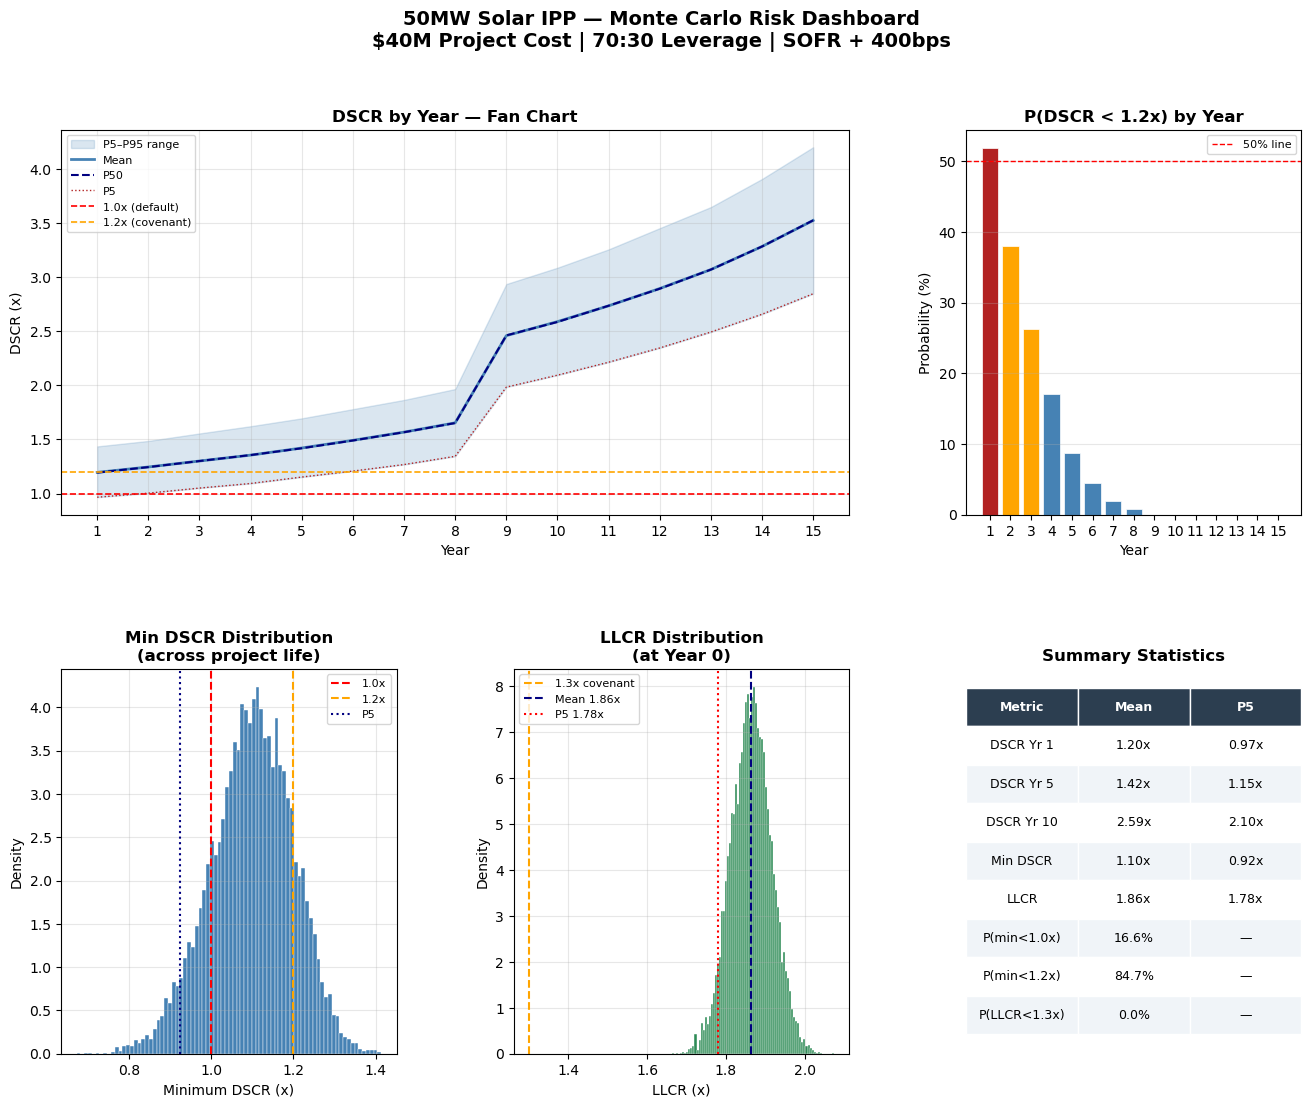

In [1]:
import numpy as np
np.random.seed(42)

n_sims  = 10_000
n_years = 20 #IPP tenor

project_cost = 40 #USD 40 million
total_loan = project_cost * 0.70 #70:30 split
IDCOL_loan = total_loan * 0.75 #75% of debt by IDCOL
other_loan = total_loan - IDCOL_loan
IDCOL_tenor = 15
other_tenor = 8
IDCOL_annual_principal = IDCOL_loan/IDCOL_tenor
other_annual_principal = other_loan/other_tenor
SOFR_base = 0.0377 #current 6M term SOFR
credit_spread = 0.04
SOFR_vol = 0.005
SOFR_path = np.random.normal(SOFR_base, SOFR_vol, size=(n_sims, n_years))
SOFR_path = np.clip(SOFR_path, 0.01, 0.1)
interest_rate = SOFR_path + credit_spread

levelized_tariff = 0.07 #7 cents per kwh
capacity = 50 #50MW
yearly_hours = 8760
average_load_factor = 0.2
generation_avg = capacity * 1000 * average_load_factor * yearly_hours
generation = np.random.normal(generation_avg, 4400000, size=(n_sims, n_years)) #std dev of 4400000 based on 5% of avg
generation = np.clip(generation, 50000000, 100000000) #floored and capped at 50000000 & 100000000 kwh
revenue = generation * levelized_tariff / 1000000
revenue = np.random.normal(revenue, 0.60 , size=(n_sims, n_years)) #std dev of 0.60 based on 10% of avg

om_avg = revenue * 0.1
om_cost = np.random.normal(om_avg, 0.06 , size=(n_sims, n_years)) #std dev of 0.06 bassed on 5% of avg
IDCOL_outstanding = np.zeros((n_sims, n_years))
for y in range(IDCOL_tenor):
    IDCOL_outstanding[:, y] = IDCOL_loan - IDCOL_annual_principal * y
other_outstanding = np.zeros((n_sims, n_years))
for y in range(other_tenor):
    other_outstanding[:, y] = other_loan - other_annual_principal * y
IDCOL_interest = IDCOL_outstanding * interest_rate
other_interest = other_outstanding * interest_rate

IDCOL_debtservice = np.where(IDCOL_outstanding > 0, IDCOL_annual_principal, 0) + IDCOL_interest
other_debtservice = np.where(other_outstanding > 0, other_annual_principal, 0) + other_interest
total_debtservice = IDCOL_debtservice + other_debtservice
active_debt = total_debtservice > 0
insurance_cost = project_cost * 0.005

EBITDA = revenue - om_cost - total_debtservice - insurance_cost

tax_rate = 0
taxable_income = revenue - om_cost - IDCOL_interest - other_interest - insurance_cost
tax = taxable_income * tax_rate

cfads = revenue - om_cost - insurance_cost - tax

dscr = np.where(active_debt, cfads / np.where(active_debt, total_debtservice, 1), np.nan)

print(f"{'Year':<6} {'Mean':>8} {'P5':>8} {'P50':>8} {'P95':>8} {'P(<1.2x)':>10}")
print("-" * 50)
for y in range(IDCOL_tenor):
    mean_d = dscr[:, y].mean()
    p5 = np.percentile(dscr[:, y], 5)
    p50 = np.median(dscr[:, y])
    p95 = np.percentile(dscr[:, y], 95)
    prob_breach = (dscr[:, y] < 1.2).mean() * 100
    print(f"  {y+1:<4} {mean_d:>8.2f}x {p5:>8.2f}x {p50:>8.2f}x {p95:>8.2f}x {prob_breach:>9.1f}%")

min_dscr_per_sim = np.nanmin(dscr, axis=1)

print(f"\nMinimum DSCR across project life:")
print(f"  Mean:                {min_dscr_per_sim.mean():.2f}x")
print(f"  5th percentile:      {np.percentile(min_dscr_per_sim, 5):.2f}x")
print(f"  P(min DSCR < 1.0x):  {(min_dscr_per_sim < 1.0).mean() * 100:.2f}%")
print(f"  P(min DSCR < 1.2x):  {(min_dscr_per_sim < 1.2).mean() * 100:.2f}%")

discount_rate = 0.08

discount_factors = 1 / (1 + discount_rate) ** np.arange(1, n_years + 1)

npv_cfads = cfads @ discount_factors

llcr = npv_cfads / total_loan

print(f"\nLLCR (at Year 0):")
print(f"  Mean:             {llcr.mean():.2f}x")
print(f"  5th percentile:   {np.percentile(llcr, 5):.2f}x")
print(f"  P(LLCR < 1.3x):  {(llcr < 1.3).mean() * 100:.2f}%")

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

years        = np.arange(1, IDCOL_tenor + 1)
dscr_active  = dscr[:, :IDCOL_tenor]
dscr_mean    = np.nanmean(dscr_active, axis=0)
dscr_p5      = np.nanpercentile(dscr_active, 5,  axis=0)
dscr_p50     = np.nanpercentile(dscr_active, 50, axis=0)
dscr_p95     = np.nanpercentile(dscr_active, 95, axis=0)

fig = plt.figure(figsize=(16, 12))
fig.suptitle("50MW Solar IPP — Monte Carlo Risk Dashboard\n$40M Project Cost | 70:30 Leverage | SOFR + 400bps",
             fontsize=14, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

#1. DSCR fan chart
ax1 = fig.add_subplot(gs[0, :2])
ax1.fill_between(years, dscr_p5, dscr_p95, alpha=0.20, color='steelblue', label='P5–P95 range')
ax1.plot(years, dscr_mean, color='steelblue',  linewidth=2,            label='Mean')
ax1.plot(years, dscr_p50,  color='navy',        linewidth=1.5, linestyle='--', label='P50')
ax1.plot(years, dscr_p5,   color='firebrick',   linewidth=1,   linestyle=':',  label='P5')
ax1.axhline(1.0, color='red',    linewidth=1.2, linestyle='--', label='1.0x (default)')
ax1.axhline(1.2, color='orange', linewidth=1.2, linestyle='--', label='1.2x (covenant)')
ax1.set_title('DSCR by Year — Fan Chart', fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('DSCR (x)')
ax1.set_xticks(years)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

#2. P(DSCR < 1.2x) breach probability by year
ax2 = fig.add_subplot(gs[0, 2])
breach_prob = [(dscr_active[:, y] < 1.2).mean() * 100 for y in range(IDCOL_tenor)]
bar_colors  = ['firebrick' if p > 50 else 'orange' if p > 20 else 'steelblue' for p in breach_prob]
ax2.bar(years, breach_prob, color=bar_colors, edgecolor='white', linewidth=0.5)
ax2.axhline(50, color='red', linestyle='--', linewidth=1, label='50% line')
ax2.set_title('P(DSCR < 1.2x) by Year', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Probability (%)')
ax2.set_xticks(years)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')

#3. Minimum DSCR distribution
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(min_dscr_per_sim, bins=80, color='steelblue', edgecolor='white', linewidth=0.3, density=True)
ax3.axvline(1.0, color='red',    linewidth=1.5, linestyle='--', label='1.0x')
ax3.axvline(1.2, color='orange', linewidth=1.5, linestyle='--', label='1.2x')
ax3.axvline(np.percentile(min_dscr_per_sim, 5), color='navy', linewidth=1.5, linestyle=':', label='P5')
ax3.set_title('Min DSCR Distribution\n(across project life)', fontweight='bold')
ax3.set_xlabel('Minimum DSCR (x)')
ax3.set_ylabel('Density')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

#4. LLCR distribution
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(llcr, bins=80, color='seagreen', edgecolor='white', linewidth=0.3, density=True)
ax4.axvline(1.3, color='orange', linewidth=1.5, linestyle='--', label='1.3x covenant')
ax4.axvline(llcr.mean(), color='navy', linewidth=1.5, linestyle='--', label=f'Mean {llcr.mean():.2f}x')
ax4.axvline(np.percentile(llcr, 5), color='red', linewidth=1.5, linestyle=':', label=f'P5 {np.percentile(llcr,5):.2f}x')
ax4.set_title('LLCR Distribution\n(at Year 0)', fontweight='bold')
ax4.set_xlabel('LLCR (x)')
ax4.set_ylabel('Density')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

#5. Summary stats table
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
stats = [
    ['Metric',       'Mean',                                       'P5'],
    ['DSCR Yr 1',    f'{dscr_mean[0]:.2f}x',                      f'{dscr_p5[0]:.2f}x'],
    ['DSCR Yr 5',    f'{dscr_mean[4]:.2f}x',                      f'{dscr_p5[4]:.2f}x'],
    ['DSCR Yr 10',   f'{dscr_mean[9]:.2f}x',                      f'{dscr_p5[9]:.2f}x'],
    ['Min DSCR',     f'{min_dscr_per_sim.mean():.2f}x',            f'{np.percentile(min_dscr_per_sim, 5):.2f}x'],
    ['LLCR',         f'{llcr.mean():.2f}x',                        f'{np.percentile(llcr, 5):.2f}x'],
    ['P(min<1.0x)',  f'{(min_dscr_per_sim<1.0).mean()*100:.1f}%',  '—'],
    ['P(min<1.2x)',  f'{(min_dscr_per_sim<1.2).mean()*100:.1f}%',  '—'],
    ['P(LLCR<1.3x)', f'{(llcr<1.3).mean()*100:.1f}%',              '—'],
]
tbl = ax5.table(cellText=stats[1:], colLabels=stats[0],
                cellLoc='center', loc='center', bbox=[0, 0.05, 1, 0.90])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#f0f4f8')
    cell.set_edgecolor('white')
ax5.set_title('Summary Statistics', fontweight='bold')

plt.savefig('ipp_dashboard.png', dpi = 150, bbox_inches = 'tight')

plt.show()